<a href="https://colab.research.google.com/github/Raymond285/stroke-risk-prediction/blob/main/stroke_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.cluster import KMeans
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             recall_score, precision_score, f1_score, roc_auc_score, silhouette_score)

In [23]:
import os
print(os.listdir("/content"))

['.config', 'healthcare-dataset-stroke-data.csv', 'sample_data']


In [24]:
df = pd.read_csv("healthcare-dataset-stroke-data.csv")
print(df.shape)
print(df.isnull().sum())
print(df["stroke"].value_counts())
df.head()

(5110, 12)
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64
stroke
0    4861
1     249
Name: count, dtype: int64


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [25]:
df = df.drop(columns=["id"])
df = df[df["gender"] != "Other"]
df.loc[(df["bmi"] < 12) | (df["bmi"] > 60), "bmi"] = np.nan
df = pd.get_dummies(df, columns=["gender", "ever_married", "work_type",
                                 "Residence_type", "smoking_status"], drop_first=True)
print("BMI missing now:", df["bmi"].isnull().sum())
print(df.shape)

BMI missing now: 217
(5109, 16)


In [26]:
X = df.drop(columns=["stroke"])
y = df["stroke"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

imputer = SimpleImputer(strategy="median")
X_train[["bmi"]] = imputer.fit_transform(X_train[["bmi"]])
X_test[["bmi"]] = imputer.transform(X_test[["bmi"]])

num_cols = ["age", "avg_glucose_level", "bmi"]
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print(X_train.shape, X_test.shape)
print("Stroke share in train:", y_train.mean().round(3))
print("Stroke share in test:", y_test.mean().round(3))

(4087, 15) (1022, 15)
Stroke share in train: 0.049
Stroke share in test: 0.049


In [27]:
from sklearn.metrics import classification_report, confusion_matrix

models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000),
    "Random Forest": RandomForestClassifier(class_weight="balanced", random_state=42),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print("=====", name, "=====")
    print(confusion_matrix(y_test, preds))
    print(classification_report(y_test, preds, digits=3))

===== Logistic Regression =====
[[715 257]
 [ 10  40]]
              precision    recall  f1-score   support

           0      0.986     0.736     0.843       972
           1      0.135     0.800     0.231        50

    accuracy                          0.739      1022
   macro avg      0.560     0.768     0.537      1022
weighted avg      0.945     0.739     0.813      1022

===== Random Forest =====
[[971   1]
 [ 50   0]]
              precision    recall  f1-score   support

           0      0.951     0.999     0.974       972
           1      0.000     0.000     0.000        50

    accuracy                          0.950      1022
   macro avg      0.476     0.499     0.487      1022
weighted avg      0.905     0.950     0.927      1022



In [28]:
rf = RandomForestClassifier(n_estimators=300, max_depth=6, min_samples_leaf=10,
                            class_weight="balanced_subsample", random_state=42)
rf.fit(X_train, y_train)
probs = rf.predict_proba(X_test)[:, 1]

for t in [0.5, 0.4, 0.3, 0.2, 0.15, 0.1]:
    p = (probs >= t).astype(int)
    print(f"cutoff {t}: recall={recall_score(y_test, p):.2f}, "
          f"precision={precision_score(y_test, p, zero_division=0):.2f}, "
          f"f1={f1_score(y_test, p):.2f}, flagged={p.sum()}")

cutoff 0.5: recall=0.80, precision=0.13, f1=0.22, flagged=309
cutoff 0.4: recall=0.84, precision=0.10, f1=0.18, flagged=409
cutoff 0.3: recall=0.84, precision=0.09, f1=0.16, flagged=464
cutoff 0.2: recall=0.86, precision=0.09, f1=0.16, flagged=496
cutoff 0.15: recall=0.90, precision=0.08, f1=0.15, flagged=558
cutoff 0.1: recall=1.00, precision=0.07, f1=0.13, flagged=730


In [29]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["recall", "precision", "f1", "roc_auc"]
lr = LogisticRegression(class_weight="balanced", max_iter=1000)

for name, model in [("Logistic Regression", lr), ("Random Forest (tuned)", rf)]:
    res = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring)
    print(name)
    for m in scoring:
        print(f"  {m}: {res['test_' + m].mean():.2f} (+/- {res['test_' + m].std():.2f})")

rf.fit(X_train, y_train)
print()
print(pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(8))

Logistic Regression
  recall: 0.81 (+/- 0.05)
  precision: 0.14 (+/- 0.01)
  f1: 0.24 (+/- 0.02)
  roc_auc: 0.84 (+/- 0.02)
Random Forest (tuned)
  recall: 0.77 (+/- 0.05)
  precision: 0.14 (+/- 0.02)
  f1: 0.23 (+/- 0.03)
  roc_auc: 0.83 (+/- 0.03)

age                        0.529264
avg_glucose_level          0.124445
bmi                        0.097309
ever_married_Yes           0.060091
hypertension               0.049845
work_type_children         0.043231
heart_disease              0.024704
work_type_Self-employed    0.014342
dtype: float64


In [30]:
cols = ["age", "avg_glucose_level", "bmi"]
Xc = X_train[cols]

scores = {}
for k in range(2, 7):
    labels = KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(Xc)
    scores[k] = silhouette_score(Xc, labels)
    print(k, round(scores[k], 3))

best_k = max(scores, key=scores.get)
print("Chosen k:", best_k)

km = KMeans(n_clusters=best_k, n_init=10, random_state=42).fit(Xc)

summary = pd.DataFrame(scaler.inverse_transform(Xc), columns=cols, index=Xc.index)
summary["cluster"] = km.labels_
summary["stroke"] = y_train.loc[Xc.index]

print(summary.groupby("cluster").agg(
    patients=("age", "size"),
    age=("age", "mean"),
    glucose=("avg_glucose_level", "mean"),
    bmi=("bmi", "mean"),
    stroke_rate=("stroke", "mean")).round(2))

2 0.302
3 0.372
4 0.368
5 0.326
6 0.317
Chosen k: 3
         patients    age  glucose    bmi  stroke_rate
cluster                                              
0             546  60.32   204.52  32.63         0.13
1            2151  54.48    89.27  31.57         0.06
2            1390  19.19    92.87  22.82         0.00


In [31]:
cols = ["age", "avg_glucose_level", "bmi", "hypertension", "heart_disease"]
iso = IsolationForest(contamination=0.05, random_state=42).fit(X_train[cols])
flag = iso.predict(X_train[cols]) == -1

real = pd.DataFrame(scaler.inverse_transform(X_train[num_cols]),
                    columns=num_cols, index=X_train.index)
real["hypertension"] = X_train["hypertension"]
real["heart_disease"] = X_train["heart_disease"]
real["anomaly"] = flag
real["stroke"] = y_train

print(real.groupby("anomaly").agg(
    patients=("age", "size"),
    age=("age", "mean"),
    glucose=("avg_glucose_level", "mean"),
    bmi=("bmi", "mean"),
    hypertension=("hypertension", "mean"),
    heart_disease=("heart_disease", "mean"),
    stroke_rate=("stroke", "mean")).round(2))

         patients    age  glucose    bmi  hypertension  heart_disease  \
anomaly                                                                 
False        3882  41.97   102.71  28.54          0.07           0.02   
True          205  67.74   166.23  32.34          0.48           0.74   

         stroke_rate  
anomaly               
False           0.04  
True            0.20  


[[715 257]
 [ 10  40]]
              precision    recall  f1-score   support

           0      0.986     0.736     0.843       972
           1      0.135     0.800     0.231        50

    accuracy                          0.739      1022
   macro avg      0.560     0.768     0.537      1022
weighted avg      0.945     0.739     0.813      1022

ROC AUC: 0.84

age                               1.89
work_type_children                0.90
hypertension                      0.62
smoking_status_smokes             0.28
avg_glucose_level                 0.21
Residence_type_Urban              0.17
heart_disease                     0.15
smoking_status_formerly smoked    0.09
bmi                               0.08
work_type_Private                 0.03
work_type_Never_worked           -0.08
gender_Male                      -0.13
ever_married_Yes                 -0.17
work_type_Self-employed          -0.21
smoking_status_never smoked      -0.24
dtype: float64


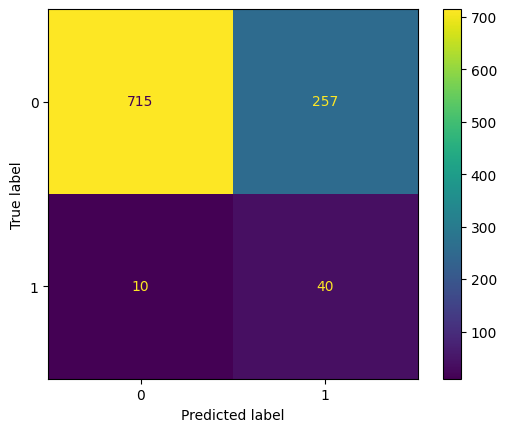

In [32]:
final = LogisticRegression(class_weight="balanced", max_iter=1000)
final.fit(X_train, y_train)

preds = final.predict(X_test)
probs = final.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, preds))
print(classification_report(y_test, preds, digits=3))
print("ROC AUC:", round(roc_auc_score(y_test, probs), 3))

print()
print(pd.Series(final.coef_[0], index=X_train.columns).sort_values(ascending=False).round(2))

ConfusionMatrixDisplay.from_predictions(y_test, preds)
plt.show()